We talk to AI chatbots every day. We type a question, and out comes a fluent.
This notebooks tells how the large language model works internally step by step. We will take a real small language model apart and rebuild the text-generation process manually, one step at a time.
We'll use a small open model called **Qwen3-0.6B** , small enough to run on a laptop.


1. **Gathering our tools** — all the libraries that are required
2. **Teaching a computer to read** — turning text into numbers (tokenization)
3. **Waking up the model** —  the "brain"
4. **Words with meaning** — turning numbers into vectors (embeddings)
5. **The model takes a guess** — prediction scores (logits)
6. **Scores to probabilities** — Doing softmax
7. **Seeing the model think** — plotting the top-20 most likely next tokens
8. **text generator** — the loop that writes


In [3]:
import torch

## Chapter 1 — Teaching a Computer to Read


A language model cannot read letters or words. It only understands numbers.
So before anything else, we need a translator that turns text into numbers. That translator is called a **tokenizer**.


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

##### Text to Numbers
'encode' splits our sentence into pieces called **tokens** and hands back an ID for each one. 

In [ ]:
tokenizer.encode("How are you Ashish? ")

[4340, 525, 498, 14595, 812, 30, 220]

Two things to understand here :
1. Tokens aren't always whole words - the name "Ashish" didn't get a single number. It was split into two pieces , 'Ash' and 'ish' .
2. Spaces also count - That last number, '220' , is the space at the end of the sentence.
To the model, ' are' (with a space) and 'are' (without space) are two completely different tokens. 

##### Numbers to Text

Let's ask what token `14595` actually is: 

In [4]:
tokenizer.decode(14595)

' Ash'

##### Packaging Our Text for the Model

In [8]:
tokenizer("How are you Ashish? ",return_type="pt")

{'input_ids': [4340, 525, 498, 14595, 812, 30, 220], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

This gave us two things: 
1. **input_ids** — the token numbers for your sentence (the same thing .encode() gave you).
2. **attention_mask** — [1, 1, 1, 1, 1, 1, 1] means that a text sequence has seven tokens, and every single token is a real, valid word or sub-word.

###### (Active) 1: Tells the transformer model to process and calculate attention scores for that token.
###### (Ignored) 0: Tells the model to ignore that token, which is typically used for artificial padding tokens added to make short sentences match the length of longer ones in a data batch

## Chapter 2 — Waking Up the Model
The tokenizer was only the translator. Now we load the actual brain.
The first time you run this,it downloads the model, so give it sometime.

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

## Chapter 3 — Turning IDs to Vector Embeddings

It turns those IDs into vector embeddings.
Let's look up the embeddings for our tokens:


In [10]:
model.model.embed_tokens(torch.tensor([4340, 525, 498, 14595, 812, 10641, 30, 220]))

tensor([[ 0.0007, -0.0083, -0.0231,  ...,  0.0167, -0.0059,  0.0188],
        [ 0.0023, -0.0085, -0.0344,  ...,  0.0098, -0.0153,  0.0513],
        [-0.0256, -0.0221, -0.0342,  ..., -0.0228,  0.0410, -0.0208],
        ...,
        [-0.0014, -0.0659,  0.0520,  ..., -0.0176,  0.0011, -0.0044],
        [-0.0400,  0.0258, -0.0425,  ..., -0.0289,  0.0437,  0.0022],
        [-0.0216,  0.0620, -0.0991,  ...,  0.0077, -0.0171,  0.0033]],
       dtype=torch.bfloat16, grad_fn=<EmbeddingBackward0>)

A little experiment to check the shape of our tokens (the tensor dimensions of data arrays).

In [11]:
torch.tensor([4340, 525, 498, 14595, 812, 30]).unsqueeze(0).shape

torch.Size([1, 6])

`unsqueeze(0)` — turning our list of 6 tokens into a batch containing one sentence of 6 tokens.

The shape `[1, 6]` reads as: **1** sentence, **6** tokens.


### Running the Model
After all the preparation, this is where we finally run the model.

The result is stored in `out`. It's an object containing the model's **logits**.Logits are the raw scores representing what the model predicts should come next, computed for every position in the sequence.

In [12]:
out = model(torch.tensor([4340, 525, 498, 14595, 812, 30]).unsqueeze(0))

In [17]:
print(out)

tensor([[ 7.5625,  4.8125,  5.5312,  ...,  0.5430,  0.5430,  0.5430],
        [ 0.9922,  1.4297, -0.1406,  ..., -2.4688, -2.4688, -2.4688],
        [ 5.7812,  5.3438,  3.7812,  ..., -1.8906, -1.8906, -1.8906],
        [11.4375,  6.2188,  4.1562,  ..., -2.1875, -2.1875, -2.1875],
        [10.8125,  4.9375,  3.9219,  ..., -3.2500, -3.2500, -3.2500],
        [ 8.0625,  4.9062,  2.9062,  ..., -0.3867, -0.3867, -0.3867]],
       dtype=torch.bfloat16, grad_fn=<SqueezeBackward1>)


These are the raw logits. 

Logits are the raw, un-processed scores that the model gives to every single word or part-word (called a token) in its dictionary. They show how much the model thinks each token should come next in a sentence

Each number is a **score, not a probability yet** which higher means "more likely to come next." These scores can be negative or large. We'll convert them into proper probabilities with softmax in the next step.

In [14]:
out = out.logits.squeeze(0)

In [16]:
print(out)

tensor([[ 7.5625,  4.8125,  5.5312,  ...,  0.5430,  0.5430,  0.5430],
        [ 0.9922,  1.4297, -0.1406,  ..., -2.4688, -2.4688, -2.4688],
        [ 5.7812,  5.3438,  3.7812,  ..., -1.8906, -1.8906, -1.8906],
        [11.4375,  6.2188,  4.1562,  ..., -2.1875, -2.1875, -2.1875],
        [10.8125,  4.9375,  3.9219,  ..., -3.2500, -3.2500, -3.2500],
        [ 8.0625,  4.9062,  2.9062,  ..., -0.3867, -0.3867, -0.3867]],
       dtype=torch.bfloat16, grad_fn=<SqueezeBackward1>)


In [19]:
out.shape

torch.Size([6, 151936])

- **6** — one row of predictions for each of the 6 input tokens.
- **151936** — the size of the model's entire vocabulary. (scored at every position)

## Chapter 4 — Raw Scores to Real Probabilities

Those logit scores are great for ranking, but they aren't probabilities.

To turn them into clean probabilities that add up to 100%, we use a function called **softmax**. It squashes the scores into values between 0 and 1 that sum to 1.

Softmax basically converts logits into probabilities.


In [21]:
torch.softmax(out[-1,:],dim=-1)

tensor([1.5545e-04, 6.6161e-06, 8.9779e-07,  ..., 3.3295e-08, 3.3295e-08,
        3.3295e-08], dtype=torch.bfloat16, grad_fn=<SoftmaxBackward0>)

## Chapter 5 — Visualizing the Possibilities

Now every one of those ~152,000 numbers is a probability. 

A picture makes this much clearer, so let's plot the **top 20** candidates.

We will visualize the top 20 candidates using python matplotlib library.

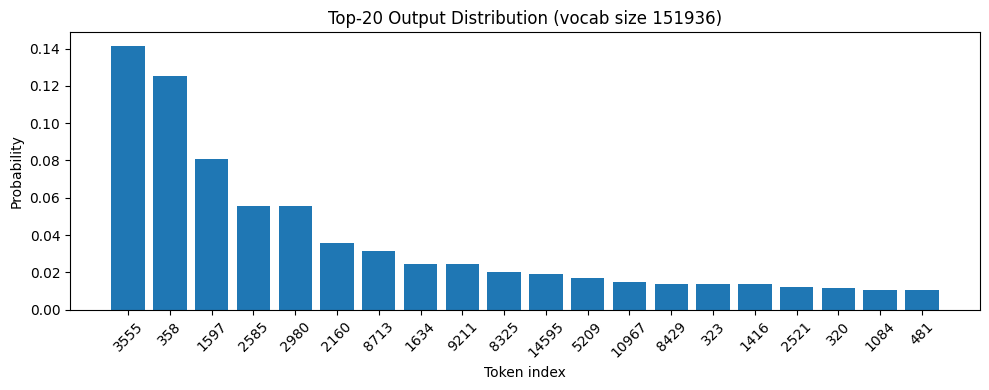

In [19]:
import matplotlib.pyplot as plt
import torch

k = 20
logits = out[-1, :]  # shape: [151936]
probs = torch.softmax(logits, dim=-1)

# do topk BEFORE converting to numpy — stays on GPU, tiny transfer
topk_probs, topk_idx = torch.topk(probs, k)

topk_probs = topk_probs.float().detach().cpu().numpy()
topk_idx = topk_idx.detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.bar(range(k), topk_probs)
plt.xticks(range(k), topk_idx, rotation=45)
plt.xlabel("Token index")
plt.ylabel("Probability")
plt.title(f"Top-{k} Output Distribution (vocab size {logits.shape[0]})")
plt.tight_layout()
plt.show()

A few things the chart shows clearly:

The top token (index `3555`) sits around 14%, the next (`358`) around 12.5%, and by the tail end each candidate is barely above 1%. Beyond these 20, the remaining ~151,900 tokens together account for almost nothing.

No single token dominates completely which means the model is confident but not certain



In [25]:
print(tokenizer.decode(3555))
print(tokenizer.decode(358))
print(tokenizer.decode(1597))
print(tokenizer.decode(2585))
print(tokenizer.decode(2980))
print(tokenizer.decode(2160))

 What
 I
 And
 How
 Can
 Is


For fun , I printed the output tokens to see their real meaning. I was curious what are the next word predictions in simple english language

## Chapter 6 — Generating Text, One Token at a Time


A model only ever predicts the *next* token. To produce a full sentence, we repeat that prediction in a loop, each time feeding the model everything generated so far. It's exactly how models like ChatGPT write text.

Using greedy decoding method for translation


In [25]:
#MANUAL text-generation loop
output = []
max_new_tokens = 8
for _ in range(max_new_tokens):
    out = model(inputs).logits
    print(out.shape) #1,6,vocab_size
    out = out[:,-1,:]
    print(out.shape) #1,vocab_size

    out = torch.softmax(out,dim=-1)

    new_token = torch.argmax(out,dim=-1)
    #new_token = new_token.item()

    if new_token.item() == tokenizer.eos_token_id:
        break

    inputs = torch.cat((inputs,new_token.view(1,-1)),dim=-1)

torch.Size([1, 6, 151936])
torch.Size([1, 151936])
torch.Size([1, 7, 151936])
torch.Size([1, 151936])
torch.Size([1, 8, 151936])
torch.Size([1, 151936])
torch.Size([1, 9, 151936])
torch.Size([1, 151936])
torch.Size([1, 10, 151936])
torch.Size([1, 151936])
torch.Size([1, 11, 151936])
torch.Size([1, 151936])
torch.Size([1, 12, 151936])
torch.Size([1, 151936])
torch.Size([1, 13, 151936])
torch.Size([1, 151936])


## Summary

Starting from a plain sentence, we walked through every stage a language model uses to generate text.

1. **Tokenization** — the text was split into tokens and converted into IDd, since the model only works with numbers. Tokens aren't always whole words, and even spaces are part of them.
2. **Embeddings** — those IDs then were turned into vectors that carry meaning.
3. **Logits** — running the model produced a raw score for every token in the ~152,000-word vocabulary, at every position in the sequence.
4. **Softmax** — those scores became a probability distribution summing to 1, showing how likely each token is to come next.
5. **Decoding** — we picked the most likely token (greedy decoding) and translated it back into text.
